In [1]:
import os
import string
import numpy as np
import matplotlib.pyplot as plt

def find_spectra_file(filename='spectra_archive.npz'):
    # Check a few common locations first (IF YOU HAVE A LARGE DRIVE YOU MIGHT WANT TO PUT THE ARCHIVE IN A COMMON LOCATION)
    checks = [
        os.path.join(os.getcwd(), filename),
        os.path.join(os.path.expanduser('~'), filename),
        os.path.join(os.path.expanduser('~'), 'Desktop', filename),
        os.path.join(os.path.expanduser('~'), 'Downloads', filename),
        os.path.join(os.path.expanduser('~'), 'Documents', filename)
    ]
    for p in checks:
        if os.path.exists(p):
            return p

    # Look for OneDrive folders under the user's home (common on Windows) Add # If this isn't necessary
    home = os.path.expanduser('~')
    try:
        for entry in os.listdir(home):
            # Match folders named 'OneDrive' or starting with 'OneDrive' (e.g. 'OneDrive - Personal')
            if entry.lower().startswith('onedrive'):
                od = os.path.join(home, entry)
                candidates = [
                    os.path.join(od, filename),
                    os.path.join(od, 'Desktop', filename),
                    os.path.join(od, 'Documents', filename),
                ]
                for c in candidates:
                    if os.path.exists(c):
                        return c
    except Exception:
        pass

    # If not found, search all available drives (Windows) or root ('/') on Unix-like systems (Again If you have a large drive...)
    roots = []
    if os.name == 'nt':
        for letter in string.ascii_uppercase:
            root = f'{letter}:\\'
            if os.path.exists(root):
                roots.append(root)
    else:
        roots.append('/')

    for root in roots:
        for dirpath, dirnames, filenames in os.walk(root):
            if filename in filenames:
                return os.path.join(dirpath, filename)
    return None

# Try to find the file automatically (Calls the find spectra function and names the file_path to where the file was found)
file_path = find_spectra_file('spectra_archive.npz')
if file_path is None:
    print('Could not find spectra_archive.npz automatically.')
    print('Place the file in this notebook folder or your Desktop/Downloads, or install it on a reachable drive.')
    raise FileNotFoundError('spectra_archive.npz not found')
else:
    print(f'Loading spectra from: {file_path}')
    data = np.load(file_path)
    print(data.files)  # List all arrays in the .npz file

# Insert here all the arrays in the .npz archive
keys = [
    "A2V_wl", "A2V_flux",
    "A6V_wl", "A6V_flux", "A9V_wl", "A9V_flux",
    "B1V_wl", "B1V_flux", "B6V_wl", "B6V_flux",
    "F0V_wl", "F0V_flux", "F5V_wl", "F5V_flux",
    "F9V_wl", "F9V_flux",
    "G6V_wl", "G6V_flux", "G9V_wl", "G9V_flux",
    "K0V_wl", "K0V_flux", "K4V_wl", "K4V_flux",
    "M0V_wl", "M0V_flux", "M1V_wl", "M1V_flux", "M5V_wl", "M5V_flux",
    "O5V_wl", "O5V_flux", "O8V_wl", "O8V_flux", "G2V_wl", "G2V_flux",
]

# If the key you've added isn't there it gives you this error
available = set(data.files)
for name in keys:
    if name in available:
        globals()[name] = data[name]
    else:
        print(f"Warning: {name} not found in the .npz archive")

Loading spectra from: c:\Users\Bruger\Desktop\Rodeskuffen\Astro Assign. 2\Workspace\spectra_archive.npz
['A2V_wl', 'A2V_flux', 'A6V_wl', 'A6V_flux', 'A9V_wl', 'A9V_flux', 'B1V_wl', 'B1V_flux', 'B6V_wl', 'B6V_flux', 'F0V_wl', 'F0V_flux', 'F5V_wl', 'F5V_flux', 'F9V_wl', 'F9V_flux', 'G2V_wl', 'G2V_flux', 'G6V_wl', 'G6V_flux', 'G9V_wl', 'G9V_flux', 'K0V_wl', 'K0V_flux', 'K4V_wl', 'K4V_flux', 'M0V_wl', 'M0V_flux', 'M1V_wl', 'M1V_flux', 'M5V_wl', 'M5V_flux', 'O5V_wl', 'O5V_flux', 'O8V_wl', 'O8V_flux']


In [ ]:
try:
    # Build spectra dict from loaded arrays (pairs like NAME_wl and NAME_flux)
    spectra = {}
    for var in list(globals().keys()):
        if var.endswith('_wl'):
            base = var[:-3]
            wl = globals().get(var)
            flux = globals().get(base + '_flux')
            if wl is not None and flux is not None:
                spectra[base] = {'wl': wl, 'flux': flux}

    import matplotlib.pyplot as plt
    try:
        import ipywidgets as widgets
        from IPython.display import display, clear_output

        if len(spectra) == 0:
            print('No spectra to select.')
        else:
            dropdown = widgets.Dropdown(options=sorted(spectra.keys()), description='Spectrum:')
            out = widgets.Output()

            def on_change(change, out=out):
                # bind `out` so this closure writes only to this cell's Output widget
                if change.get('name') == 'value':
                    with out:
                        clear_output(wait=True)
                        n = change.get('new')
                        wl = spectra[n]['wl']
                        flux = spectra[n]['flux']
                        plt.figure(figsize=(9,4))
                        plt.plot(wl, flux, lw=0.8)
                        plt.xlabel('Wavelength (Å)')
                        plt.ylabel('Flux (erg s^-1 cm^-2 Å^-1)')
                        plt.title(n)
                        plt.grid(True)
                        plt.show()

            dropdown.observe(on_change, names='value')
            display(dropdown, out)
    except Exception as e:
        print('To enable interactive selection install ipywidgets:')
        print('pip install ipywidgets')
        print('Then enable notebook extension if needed (classic notebook). Error:', e)
except Exception as e:
    print('Error building spectra dictionary:', e)

Dropdown(description='Spectrum:', options=('A2V', 'A6V', 'A9V', 'B1V', 'B6V', 'F0V', 'F5V', 'F9V', 'G2V', 'G6V…

Output()

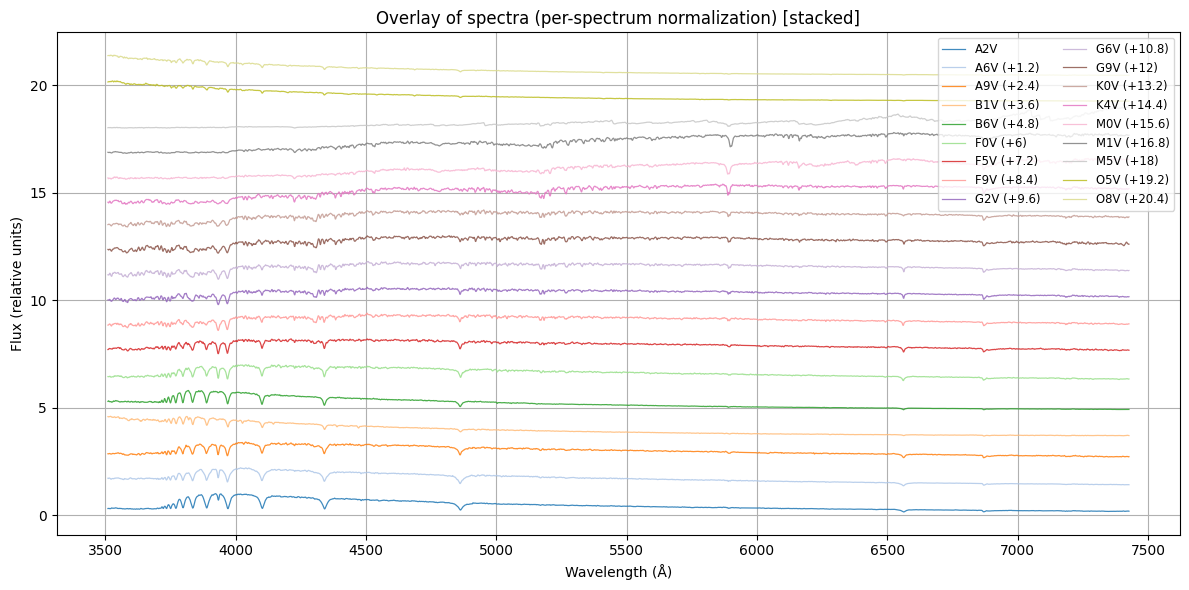

In [3]:
# Overlay with per-spectrum scaling (optionally stack vertically using offsets)
try:
    # Rebuild spectra dict in case it's not present in this scope
    spectra = {}
    for var in list(globals().keys()):
        if var.endswith('_wl'):
            base = var[:-3]
            wl = globals().get(var)
            flux = globals().get(base + '_flux')
            if wl is not None and flux is not None:
                spectra[base] = {'wl': wl, 'flux': flux}

    if len(spectra) == 0:
        print('No spectra available to plot. Make sure the .npz file was loaded successfully.')
    else:
        # Per-spectrum scaling: set scalars here (keys are spectrum names without _wl/_flux)
        # Example: scales = {'A2V': 1.0, 'G9V': 0.5} to plot G9V at half the height of A2V (THIS ISN'T NECESSARY WHEN USING STACKING)
        scales = {
            'A2V': 1.0,
            'A6V': 1.0,
            'A9V': 1.0,
            'B1V': 1.0,
            'B6V': 1.0,
            'F0V': 1.0,
            'F5V': 1.0,
            'F9V': 1.0,
            'G2V': 1.0,
            'G6V': 1.0,
            'G9V': 1.0,
            'K0V': 1.0,
            'K4V': 1.0,
            'M0V': 1.0,
            'M1V': 1.0,
            'M5V': 1.0,
            'O5V': 1.0,
            'O8V': 1.0,
        }

        # Option: stack spectra vertically instead of plotting on the same baseline.
        # - Set `offset_mode = False` to keep the overlay behavior.
        # - If `offset_mode = True` you can provide per-spectrum additive offsets in `offsets`.
        # - When stacking we use per-spectrum normalization and then apply `scales` so multipliers
        #   increase the apparent height of a spectrum within its stack position (ladder behavior).
        offset_mode = True
        offsets = {name: 0.0 for name in spectra.keys()}  # user-editable per-spectrum offsets (additive, in the same units as plotted values)

        # Decide normalization mode for non-stacked plots:
        # - If all scales == 1.0 -> use per-spectrum normalization (original behavior)
        # - If any scale != 1.0 -> compute global max after scaling and normalize by that (preserve relative amplitudes)
        use_global_norm = any(v != 1.0 for v in scales.values())
        if offset_mode:
            # For stacked plotting we prefer per-spectrum normalization so each spectrum retains its own shape.
            use_global_norm = False

        # First compute (optionally scaled) maxima if global normalization is requested
        global_max = 0.0
        if use_global_norm:
            for name, s in spectra.items():
                raw_f = np.asarray(s['flux'], dtype=float)
                f = raw_f * scales.get(name, 1.0)
                if f.size == 0:
                    continue
                m = np.nanmax(np.abs(f))
                if np.isfinite(m) and m > global_max:
                    global_max = m

        import matplotlib.pyplot as plt
        cmap = plt.get_cmap('tab20')
        plt.figure(figsize=(12, 6))

        # Precompute plotted fluxes so we can apply automatic offsets when requested
        plotted = {}
        names_sorted = sorted(spectra.keys())
        for name in names_sorted:
            wl = np.asarray(spectra[name]['wl'], dtype=float)
            raw_f = np.asarray(spectra[name]['flux'], dtype=float)
            if raw_f.size == 0:
                plotted[name] = (wl, raw_f, 0.0)
                continue

            if use_global_norm:
                # global normalization: scale applied before normalization so relative amplitudes preserved
                f_scaled = raw_f * scales.get(name, 1.0)
                if global_max > 0:
                    f_plot = f_scaled / global_max
                else:
                    f_plot = f_scaled
            else:
                # per-spectrum normalization
                maxval = np.nanmax(np.abs(raw_f))
                if maxval == 0 or np.isnan(maxval):
                    f_norm = raw_f
                else:
                    f_norm = raw_f / maxval
                # If stacking, multiply by scale after normalization so scale increases apparent height
                if offset_mode:
                    f_plot = f_norm * scales.get(name, 1.0)
                else:
                    # non-stacked per-spectrum normalization already accounts for scale via earlier branch
                    f_plot = f_norm

            # store peak for automatic spacing
            peak = 0.0
            try:
                peak = float(np.nanmax(np.abs(f_plot))) if f_plot.size else 0.0
            except Exception:
                peak = 0.0

            plotted[name] = (wl, f_plot, peak)

        # If offset_mode is enabled, compute final offsets
        final_offsets = {name: float(offsets.get(name, 0.0)) for name in names_sorted}
        if offset_mode:
            # if user didn't provide any non-zero offsets, create automatic spacing
            if all(v == 0.0 for v in final_offsets.values()):
                # Determine a spacing based on the median peak of the plotted spectra
                peaks = [p[2] for p in plotted.values() if p[2] is not None and p[2] > 0]
                if len(peaks) == 0:
                    sep = 1.0
                else:
                    sep = 1.2 * float(np.nanmedian(peaks))
                    if sep == 0 or not np.isfinite(sep):
                        sep = 1.0
                for i, name in enumerate(names_sorted):
                    final_offsets[name] = i * sep
            # otherwise keep user-specified offsets (already in final_offsets)

        # Plot each spectrum, applying offsets when requested
        ax = plt.gca()
        for i, name in enumerate(names_sorted):
            wl, f_plot, _ = plotted[name]
            if f_plot.size == 0:
                continue

            offset = final_offsets.get(name, 0.0) if offset_mode else 0.0
            label = name
            # For stacked plots we applied scales to plotted values; for non-stacked we indicate scale in label
            if not offset_mode and scales.get(name, 1.0) != 1.0:
                label = f"{name} (×{scales.get(name)})"
            if offset_mode and float(offset) != 0.0:
                label = f"{label} (+{offset:g})"

            ax.plot(wl, f_plot + offset, label=label, color=cmap(i % 20), lw=0.9, alpha=0.85)

        # Ensure axis limits include stacked offsets
        ax.relim()
        ax.autoscale_view()

        plt.xlabel('Wavelength (Å)')
        plt.ylabel('Flux (relative units)')
        title_extra = ' (global normalization)' if use_global_norm else ' (per-spectrum normalization)'
        if offset_mode:
            title_extra += ' [stacked]'
        plt.title('Overlay of spectra' + title_extra)
        plt.grid(True)
        try:
            plt.legend(loc='upper right', fontsize='small', ncol=2)
        except Exception:
            plt.legend(fontsize='small')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print('Error plotting overlay with per-spectrum scaling:', e)

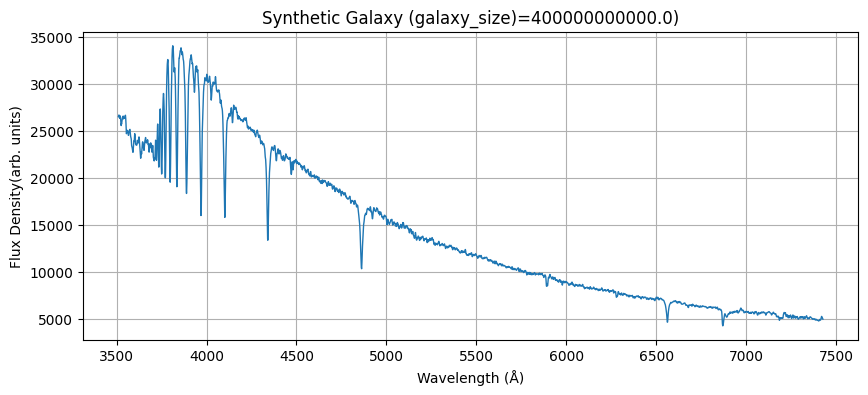

Output()

In [4]:
# Build class spectra and galaxy builder (per-class multipliers) with per-member weights
# Usage examples:
#   set_class_member_weights('O', {'O5V':0.25, 'O8V':0.75})
#   wl_o, flux_o = build_class_spectrum('O')
#   wl_gal, flux_gal = build_galaxy_spectrum({'O':50, 'G':1000})
try:
    # Ensure spectra dict exists (rebuild from globals if necessary)
    spectra = {}
    for var in list(globals().keys()):
        if var.endswith('_wl'):
            base = var[:-3]
            wl = globals().get(var)
            flux = globals().get(base + '_flux')
            if wl is not None and flux is not None:
                spectra[base] = {'wl': wl, 'flux': flux}

    # Define class membership for available spectra (Theoretically we could include every single star type)
    classes = {
        'O': ['O5V', 'O8V'],
        'B': ['B1V', 'B6V'],
        'A': ['A2V', 'A6V', 'A9V'],
        'F': ['F0V', 'F5V', 'F9V'],
        'G': ['G6V', 'G9V', 'G2V'],
        'K': ['K0V', 'K4V'],
        'M': ['M0V', 'M1V', 'M5V'],
    }

    import numpy as np
    import matplotlib.pyplot as plt

    # Default per-member weights for classes (will be overridden with set_class_member_weights)
    # By default we distribute weight equally among listed members (This is just building a base for the code to work upon. dw)
    default_member_weights = {}
    for c, members in classes.items():
        if len(members) > 0:
            w = 1.0 / len(members)
            default_member_weights[c] = {m: w for m in members}
        else:
            default_member_weights[c] = {}

    def set_class_member_weights(class_name, weights_dict, normalize=True): # Set per-member weights for a class.
        """Set per-member weights for a class.

        - class_name: one-letter class (e.g. 'O').
        - weights_dict: mapping member_name -> weight (e.g. {'O5V':0.25, 'O8V':0.75}).
        - normalize: if True (default) scales weights so they sum to 1.0.
        """
        cname = class_name.upper()
        if cname not in classes:
            raise ValueError(f"Unknown class '{class_name}'. Available: {list(classes.keys())}")
        # Keep only members that belong to class (If we were to add a class H102V it would be ignored)
        members = classes[cname]
        filtered = {m: float(weights_dict.get(m, 0.0)) for m in members}
        if normalize:
            total = sum(filtered.values())
            if total > 0:
                filtered = {m: v / total for m, v in filtered.items()}
            else:
                # If total is zero, fallback to equal weights (Makes sure the code doesn't hang)
                filtered = {m: 1.0 / max(1, len(members)) for m in members}
        default_member_weights[cname] = filtered
        return default_member_weights[cname]

    def get_class_members(class_name): # Return list of member names for a class.
        cname = class_name.upper()
        if cname not in classes:
            raise ValueError(f"Unknown class '{class_name}'.")
        return classes[cname]

    # Cache for class spectra (summed without per-class multiplier)
    class_spectra = {}

    def build_class_spectrum(class_name, member_weights=None, ref_wl=None, normalize_weights=True): # Build summed spectrum for a class.
        """Return (wl, flux) for the summed class spectrum (no multiplier applied).

        - class_name: one-letter class (e.g. 'O', 'G').
        - member_weights: optional dict mapping member name -> weight applied before summing.
                          If None, the stored `default_member_weights` for that class are used.
        - ref_wl: optional reference wavelength grid (1D array). If None, the first available member's wl is used.
        - normalize_weights: if True, weights are normalized to sum to 1.0 before use.
        """
        cname = class_name.upper()
        if cname not in classes:
            raise ValueError(f"Unknown class '{class_name}'. Available: {list(classes.keys())}")

        members = [m for m in classes[cname] if m in spectra]
        if len(members) == 0:
            raise ValueError(f"No spectra available for class '{cname}'")

        # Select weights: provided -> use; otherwise stored defaults
        weights = None
        if member_weights is not None:
            weights = {m: float(member_weights.get(m, 0.0)) for m in members}
        else:
            weights = {m: float(default_member_weights.get(cname, {}).get(m, 1.0)) for m in members}

        if normalize_weights:
            total = sum(weights.values())
            if total > 0:
                weights = {m: w / total for m, w in weights.items()}
            else:
                # fallback to equal weights
                weights = {m: 1.0 / len(members) for m in members}

        # Use provided ref_wl or the first member's wl
        if ref_wl is None: # use first member's wl
            ref_wl = np.asarray(spectra[members[0]]['wl'], dtype=float) # Convert to numpy array
        else: # use provided ref_wl
            ref_wl = np.asarray(ref_wl, dtype=float) # Convert to numpy array

        summed = np.zeros_like(ref_wl, dtype=float) # Initialize summed flux array
        for m in members:
            wl_m = np.asarray(spectra[m]['wl'], dtype=float) # Convert to numpy array
            flux_m = np.asarray(spectra[m]['flux'], dtype=float) # Convert to numpy array
            # Interpolate flux to reference grid; out-of-range values -> 0
            f_interp = np.interp(ref_wl, wl_m, flux_m, left=0.0, right=0.0) # Interpolation
            weight = weights.get(m, 0.0) # Get weight for member
            summed += f_interp * weight # Weighted sum

        # Cache by class (note: if different ref_wl used later, cache won't match)
        class_spectra[cname] = (ref_wl, summed)
        return ref_wl, summed

    def build_galaxy_spectrum(class_multipliers, ref_wl=None, member_weights=None, res=5000): # Build galaxy spectrum from class spectra and multipliers.
        """Sum class spectra using per-class multipliers.

        - class_multipliers: dict mapping class letter -> multiplier (e.g. {'O':50, 'G':1000})
        - ref_wl: optional reference grid. If None, a common grid spanning all member ranges is created.
        - member_weights: optional dict mapping class -> {member: weight} (overrides defaults)
        - res: number of points for auto-generated reference grid when ref_wl is None.
        Returns (ref_wl, galaxy_flux)
        """
        # Determine which classes are requested and available
        selected = {c: v for c, v in class_multipliers.items() if c.upper() in classes and v != 0} # Filter valid classes
        if len(selected) == 0:
            raise ValueError('No valid classes provided in class_multipliers') # Check for valid classes

        # If no ref grid provided, find overall min/max wl across selected members
        if ref_wl is None: # create common grid
            min_wl = np.inf # Initialize min_wl
            max_wl = -np.inf # Initialize max_wl
            for c in selected: # Iterate over selected classes
                for m in classes[c.upper()]:
                    if m in spectra:
                        wl_m = np.asarray(spectra[m]['wl'], dtype=float)
                        if wl_m.size:
                            min_wl = min(min_wl, wl_m.min())
                            max_wl = max(max_wl, wl_m.max())
            if not np.isfinite(min_wl) or not np.isfinite(max_wl) or min_wl >= max_wl: # Check if valid range
                raise ValueError('Unable to determine wavelength range for selected classes') # Raise error if invalid
            # Create reference wavelength grid
            ref_wl = np.linspace(min_wl, max_wl, res) # Linear grid
        else:
            ref_wl = np.asarray(ref_wl, dtype=float) # Convert to numpy array

        galaxy = np.zeros_like(ref_wl, dtype=float) # Initialize galaxy flux array
        for c, mult in selected.items(): # Iterate over selected classes
            weights_for_class = None # Initialize weights for class
            if member_weights and c in member_weights: # Check if member weights provided for class
                weights_for_class = member_weights[c] # Get weights for class
            try:
                _, class_flux = build_class_spectrum(c, member_weights=weights_for_class, ref_wl=ref_wl) # Build class spectrum
            except Exception as e:
                # skip missing class (Making sure the function doesn't fail completely if one class is missing)
                print(f"Skipping class {c}: {e}")
                continue
            galaxy += class_flux * mult # Add weighted class flux to galaxy

        return ref_wl, galaxy # Return reference wavelength and galaxy flux

    # Example: set specific star-class weights and build a small example using a user-specified galaxy_size
    try:
        # Set per-member weights of each class of stars
        set_class_member_weights('O', {'O5V': 0.34, 'O8V': 0.66})
        set_class_member_weights('A', {'A2V': 0.15, 'A6V': 0.35, 'A9V': 0.50})
        set_class_member_weights('B', {'B1V': 0.20, 'B6V': 0.80})
        set_class_member_weights('F', {'F0V': 0.10, 'F5V': 0.25, 'F9V': 0.65})
        set_class_member_weights('G', {'G2V': 0.15, 'G6V': 0.35, 'G9V': 0.50})
        set_class_member_weights('K', {'K0V': 0.35, 'K4V': 0.65})
        set_class_member_weights('M', {'M0V': 0.15, 'M1V': 0.35, 'M5V': 0.50})

        # Specify galaxy_size (i.e what number of total stars do we want).
        galaxy_size = 400e9

        # Build a components dict that specifies how many of each type we want
        comps = {
            'O': 0.000003 * galaxy_size,
            'A': 0.06 * galaxy_size,
            'B': 0.013 * galaxy_size,
            'F': 0.03 * galaxy_size,
            'G': 0.76 * galaxy_size,
            'K': 0.121 * galaxy_size,
            'M': 0.765 * galaxy_size,
        }

        # Build the galaxy spectrum using the currently stored member weights
        wl_gal, flux_gal = build_galaxy_spectrum(comps)

        # Save to globals for later use (idk this probably isn't necessary, let's see what the future assignments are)
        globals()['last_galaxy'] = (wl_gal, flux_gal)
        globals()['last_galaxy_components'] = comps
        globals()['galaxy_size'] = galaxy_size

        # Plot the result (duh)
        plt.figure(figsize=(10,4))
        plt.plot(wl_gal, flux_gal, lw=1.0)
        plt.xlabel('Wavelength (Å)')
        plt.ylabel('Flux Density(arb. units)')
        plt.title(f'Synthetic Galaxy (galaxy_size)={galaxy_size})')
        plt.grid(True)
        plt.show()
    except Exception as e: # If anything were to go wrong this shit would fire
        print('Example galaxy weights/plot skipped:', e)

except Exception as e: #if anything were to go wrong this shit would fire
    print('Error setting up weighted class spectra:', e)

# --- Interactive class viewer + overlay (dropdown) ---
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    # class_colors: define which colors we want each class to have
    class_colors = {
        'O': 'tab:blue',
        'B': 'tab:orange',
        'A': 'tab:green',
        'F': 'tab:red',
        'G': 'tab:purple',
        'K': 'tab:brown',
        'M': 'tab:gray',
    }
    # We'll make a function giving us the spectra of the synthetic galaxy as well as giving us the spectra for each
    # star class, as well as giving us the option to overlay the galaxy spectrum so we can compare them to see which 
    # class contributes what.
    def plot_class_and_optional_galaxy(class_name, overlay_galaxy=False):
        """Plot the summed class spectrum and optionally overlay the (simple normalized) galaxy spectrum.

        Both the class spectrum and the galaxy spectrum are normalized by dividing by their maximum absolute value
        so the plotted amplitudes are directly comparable (simple division as requested).
        """
        cname = class_name.upper()
        try:
            wl_c, flux_c = build_class_spectrum(cname)
        except Exception as e:
            print(f"Unable to build class spectrum for {cname}: {e}")
            return

        # Normalize class spectrum by its max (avoid division by zero)
        maxc = float(np.nanmax(np.abs(flux_c))) if (hasattr(flux_c, 'size') and flux_c.size) else 1.0
        if maxc == 0 or not np.isfinite(maxc):
            maxc = 1.0
        flux_c_norm = flux_c / maxc

        fig, ax = plt.subplots(figsize=(9, 4))
        color = class_colors.get(cname, 'k')
        ax.plot(wl_c, flux_c_norm, color=color, lw=1.4, label=f"{cname} class (normalized)", zorder=2)

        if overlay_galaxy: # Overlay galaxy if requested
            if 'last_galaxy' not in globals():
                print('No galaxy spectrum available — run the galaxy builder example first.')
            else:
                wl_gal, flux_gal = globals()['last_galaxy']
                # Simple normalization by max magnitude (avoid division by zero)
                maxg = float(np.nanmax(np.abs(flux_gal))) if (hasattr(flux_gal, 'size') and flux_gal.size) else 1.0
                if maxg == 0 or not np.isfinite(maxg):
                    maxg = 1.0
                gal_norm = flux_gal / maxg
                # Interpolate galaxy onto class wavelength grid and plot
                gal_interp = np.interp(wl_c, wl_gal, gal_norm, left=0.0, right=0.0)
                ax.plot(wl_c, gal_interp, color='0.4', lw=1.0, alpha=0.8, label='Galaxy (normalized)', zorder=1)

        ax.set_xlabel('Wavelength (Å)')
        ax.set_ylabel('Normalized flux (max=1)')
        ax.set_title(f"Class {cname} spectrum{(' + galaxy' if overlay_galaxy else '')}")
        ax.grid(True)
        ax.legend(fontsize='small')
        plt.show()

    # Widgets: dropdown for class, checkbox to overlay galaxy
    if len(classes) == 0:
        print('No classes available for interactive viewer')
    else:
        class_dropdown = widgets.Dropdown(options=sorted(classes.keys()), description='Class:')
        overlay_checkbox = widgets.Checkbox(value=False, description='Overlay galaxy')
        out = widgets.Output()

        def _update(change=None, out=out):
            # bind `out` here to ensure this updater writes to the correct Output widget
            with out:
                clear_output(wait=True)
                plot_class_and_optional_galaxy(class_dropdown.value, overlay_checkbox.value)

        class_dropdown.observe(_update, names='value')
        overlay_checkbox.observe(_update, names='value')

        display(widgets.HBox([class_dropdown, overlay_checkbox]), out)

except Exception as e:
    print('To enable interactive class viewer install ipywidgets:', e)
    print('    pip install ipywidgets')

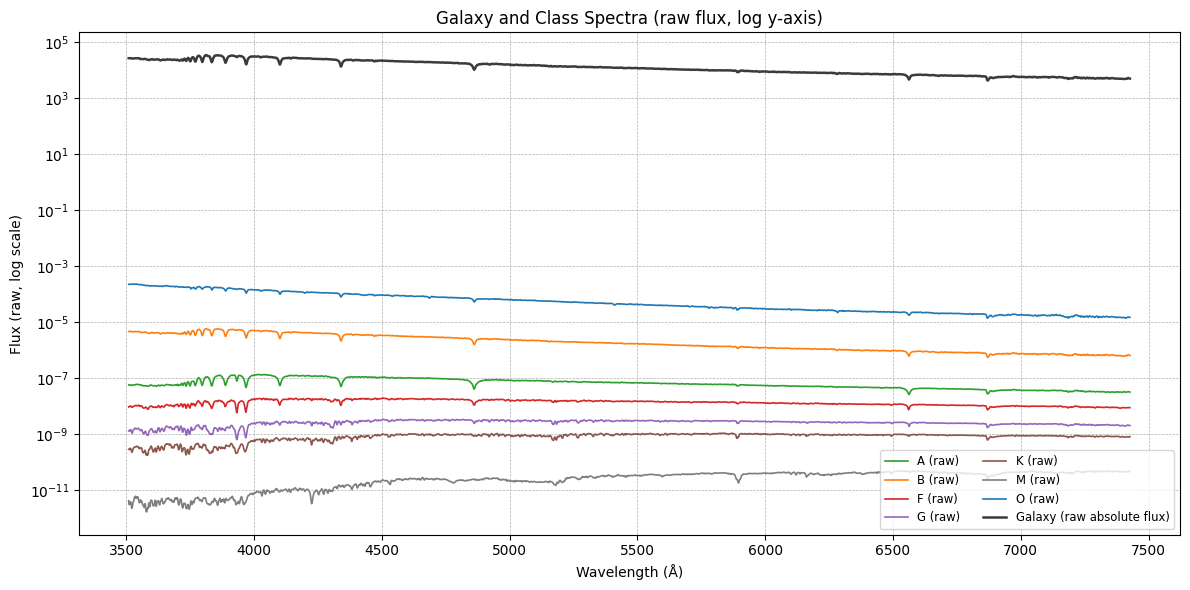

In [5]:
# Combined plot: galaxy spectrum + all class spectra on a log y-axis (RAW FLUX, no normalization)
# - Uses raw absolute flux for each class and for the galaxy (no normalization),
#   applies a small additive floor for log scale, and multiplicative offsets
#   so the traces remain visually separated on the log axis.
# - `spacing_exponent` controls how much vertical separation is applied per class:
#     factor = 10**(i * spacing_exponent)
#   Smaller `spacing_exponent` -> less separation. Set to 0 for no offsets.

import numpy as np
import matplotlib.pyplot as plt

# Check prerequisites
if 'spectra' not in globals() or len(spectra) == 0:
    raise RuntimeError('spectra dictionary not found. Run the earlier loading cell first.')

# Obtain galaxy spectrum (use last_galaxy if present, otherwise try to build a simple example)
wl_gal = None
flux_gal = None
if 'last_galaxy' in globals():
    wl_gal, flux_gal = globals()['last_galaxy']
else:
    try:
        # Use the most recently constructed galaxy components when available so the plotted
        # galaxy represents the synthetic model the user created earlier in the notebook.
        if 'last_galaxy_components' in globals():
            comps_try = globals()['last_galaxy_components']
        elif 'comps' in globals():
            comps_try = globals()['comps']
        elif 'galaxy_size' in globals():
            # If only `galaxy_size` is present, reconstruct components using the same
            # fraction scheme used by the example builder so totals scale with galaxy_size.
            gs = float(globals()['galaxy_size'])
            comps_try = {
                'O': 0.000003 * gs,
                'A': 0.06 * gs,
                'B': 0.013 * gs,
                'F': 0.03 * gs,
                'G': 0.76 * gs,
                'K': 0.121 * gs,
                'M': 0.765 * gs,
            }
        else:
            # No user-provided components: raise to make the situation explicit instead of
            # falling back to arbitrary small example numbers that don't reflect the synthetic galaxy.
            raise RuntimeError('No galaxy components found. Run the galaxy builder example first to create `last_galaxy_components` or set `comps`/`galaxy_size`.')
        wl_gal, flux_gal = build_galaxy_spectrum(comps_try)
    except Exception as e:
        print('No galaxy spectrum available and build attempt failed:', e)

# Classes list (fallback to unique first-letter groups if `classes` not available)
if 'classes' in globals() and isinstance(classes, dict) and len(classes) > 0:
    class_list = sorted(classes.keys())
else:
    # derive classes from spectra keys (first character)
    class_list = sorted({name[0] for name in spectra.keys()})

# Prepare plot (plot raw flux for all traces with no multiplicative offsets)
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.get_cmap('tab10')

tiny = 1e-30  # small floor to avoid zeros on log scale

for i, cname in enumerate(class_list):
    try:
        wl_c, flux_c = build_class_spectrum(cname)
    except Exception as e:
        # skip missing/unbuildable classes
        print(f'Skipping class {cname}:', e)
        continue

    # Use raw absolute flux (no normalization, no multiplication)
    if not (hasattr(flux_c, 'size') and flux_c.size):
        print(f'Class {cname} has empty flux array; skipping')
        continue
    y_raw = np.abs(np.asarray(flux_c, dtype=float)) + tiny

    # Do NOT apply any multiplicative offsets — plot raw flux directly
    y = y_raw

    color = class_colors.get(cname, colors(i % 10)) if 'class_colors' in globals() else colors(i % 10)
    ax.plot(wl_c, y, label=f"{cname} (raw)", color=color, lw=1.2)

# Plot galaxy if available — DO NOT normalize the galaxy (plot raw absolute flux)
if wl_gal is not None and flux_gal is not None:
    gal_y = np.abs(np.asarray(flux_gal, dtype=float)) + tiny
    # Plot galaxy using its raw absolute flux on the same log axis
    ax.plot(wl_gal, gal_y, color='0.15', lw=1.8, alpha=0.9, label='Galaxy (raw absolute flux)')

ax.set_yscale('log')
ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (raw, log scale)')
ax.set_title('Galaxy and Class Spectra (raw flux, log y-axis)')
ax.grid(True, which='both', ls='--', lw=0.5)
ax.legend(fontsize='small', ncol=2)
plt.tight_layout()
plt.show()

gal1.fits wavelength array (length=1743):
[1235. 1240. 1245. ... 9935. 9940. 9945.]

gal2.fits wavelength array (length=1741):
[1235. 1240. 1245. ... 9925. 9930. 9935.]

Synthetic galaxy wavelength array (length=5000):
[3510.         3510.78359676 3511.56719352 ... 7425.63300648 7426.41660324
 7427.2002    ]


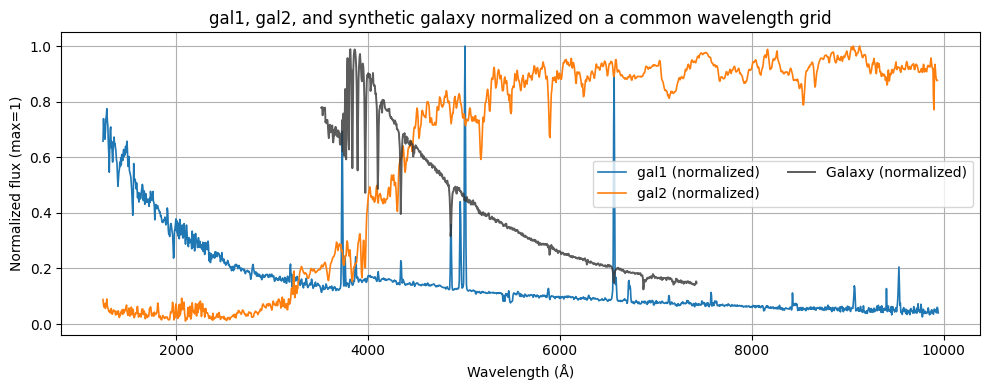

In [6]:
# Read gal1.fits and gal2.fits, extract wavelength arrays, and print them
# Also print the wavelength array from the synthetic galaxy (built in Cell 4)
# Additionally: plot gal1 and gal2 spectra using the extracted arrays, overlay the synthetic galaxy,
# and normalize all three traces for direct comparison on a single common wavelength grid

import os
import numpy as np
import matplotlib.pyplot as plt

# Try to use astropy for FITS I/O; if unavailable, guide user to install it
try:
    from astropy.io import fits
except Exception as e:
    print('Astropy not found. Install it to read FITS files:')
    print('    pip install astropy')
    raise


def get_wavelength_array(hdul):
    """Extract wavelength array from a FITS HDUList.

    Tries common patterns:
    - Primary/first image HDU with linear WCS via CRVAL1, CDELT1, CRPIX1, NAXIS1
    - Table HDU with a column named one of ['wavelength','WAVELENGTH','lambda','LAMBDA','wave','WAVE']
    Returns a 1D numpy array or raises ValueError if not found.
    """
    # 1) Look for table columns first
    for hdu in hdul:
        if hasattr(hdu, 'data') and hdu.data is not None:
            if getattr(hdu, 'columns', None) is not None:
                colnames = [c.name for c in hdu.columns]
                for name in ['wavelength', 'WAVELENGTH', 'lambda', 'LAMBDA', 'wave', 'WAVE']:
                    if name in colnames:
                        data = hdu.data[name]
                        arr = np.asarray(data, dtype=float).ravel()
                        if arr.size:
                            return arr
                # If a single-column table, assume it's wavelength
                if len(colnames) == 1:
                    data = hdu.data[colnames[0]]
                    arr = np.asarray(data, dtype=float).ravel()
                    if arr.size:
                        return arr
    
    # 2) Try image HDU with linear WCS keywords
    for hdu in hdul:
        hdr = getattr(hdu, 'header', None)
        data = getattr(hdu, 'data', None)
        if hdr is None:
            continue
        # Common linear dispersion keywords
        crval1 = hdr.get('CRVAL1')
        cdelt1 = hdr.get('CDELT1', hdr.get('CD1_1'))
        crpix1 = hdr.get('CRPIX1')
        naxis1 = hdr.get('NAXIS1') or (data.shape[1] if (data is not None and data.ndim == 2) else (data.shape[0] if (data is not None and data.ndim == 1) else None))
        if crval1 is not None and cdelt1 is not None and crpix1 is not None and naxis1 is not None:
            # FITS indexing: wavelength[i] = CRVAL1 + (i+1 - CRPIX1) * CDELT1
            i = np.arange(1, int(naxis1) + 1, dtype=float)
            wl = crval1 + (i - crpix1) * cdelt1
            return np.asarray(wl, dtype=float)
    
    raise ValueError('No wavelength information found in FITS file (no table column and no linear WCS keywords).')


def get_flux_array(hdul):
    """Extract flux array from a FITS HDUList.

    Tries table columns named ['flux','FLUX','intensity','INTENSITY'].
    If an image HDU is present, returns the first row/column as 1D flux depending on shape.
    """
    # 1) Table columns
    for hdu in hdul:
        if hasattr(hdu, 'data') and hdu.data is not None:
            if getattr(hdu, 'columns', None) is not None:
                colnames = [c.name for c in hdu.columns]
                for name in ['flux', 'FLUX', 'intensity', 'INTENSITY']:
                    if name in colnames:
                        data = hdu.data[name]
                        arr = np.asarray(data, dtype=float).ravel()
                        if arr.size:
                            return arr
                # If there are exactly two columns, assume second is flux
                if len(colnames) == 2:
                    data = hdu.data[colnames[1]]
                    arr = np.asarray(data, dtype=float).ravel()
                    if arr.size:
                        return arr
    # 2) Image HDU
    for hdu in hdul:
        data = getattr(hdu, 'data', None)
        if data is None:
            continue
        arr = np.asarray(data, dtype=float)
        if arr.ndim == 1:
            return arr
        if arr.ndim == 2:
            # Assume spectra in rows; take the first row
            return arr[0, :]
    raise ValueError('No flux data found in FITS file (no table column and no image data).')


def read_wavelengths_and_flux(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    with fits.open(path) as hdul:
        wl = get_wavelength_array(hdul)
        flux = get_flux_array(hdul)
        # Align sizes if needed
        n = min(wl.size, flux.size)
        return wl[:n], flux[:n]

# Assume files are in the same folder as the notebook
nb_dir = os.getcwd()
file1 = os.path.join(nb_dir, 'gal1.fits')
file2 = os.path.join(nb_dir, 'gal2.fits')

# Read and print full arrays
wl_gal1 = None
wl_gal2 = None
flux_gal1 = None
flux_gal2 = None
try:
    wl_gal1, flux_gal1 = read_wavelengths_and_flux(file1)
    print(f"gal1.fits wavelength array (length={wl_gal1.size}):")
    print(wl_gal1)
except Exception as e:
    print('Failed to read wavelengths from gal1.fits:', e)

try:
    wl_gal2, flux_gal2 = read_wavelengths_and_flux(file2)
    print(f"\ngal2.fits wavelength array (length={wl_gal2.size}):")
    print(wl_gal2)
except Exception as e:
    print('Failed to read wavelengths from gal2.fits:', e)

# Print synthetic galaxy wavelengths from Cell 4 and get flux for overlay
gal_wl = None
gal_flux = None
try:
    if 'last_galaxy' in globals():
        gal_wl, gal_flux = globals()['last_galaxy']
    else:
        # Attempt to reconstruct using previous components if available
        comps_try = None
        if 'last_galaxy_components' in globals():
            comps_try = globals()['last_galaxy_components']
        elif 'comps' in globals():
            comps_try = globals()['comps']
        elif 'galaxy_size' in globals():
            gs = float(globals()['galaxy_size'])
            comps_try = {
                'O': 0.000003 * gs,
                'A': 0.06 * gs,
                'B': 0.013 * gs,
                'F': 0.03 * gs,
                'G': 0.76 * gs,
                'K': 0.121 * gs,
                'M': 0.765 * gs,
            }
        if comps_try is not None:
            gal_wl, gal_flux = build_galaxy_spectrum(comps_try)
    if gal_wl is not None:
        gal_wl = np.asarray(gal_wl, dtype=float)
        print(f"\nSynthetic galaxy wavelength array (length={gal_wl.size}):")
        print(gal_wl)
    else:
        print("\nSynthetic galaxy wavelengths unavailable. Run Cell 4 to build 'last_galaxy'.")
except Exception as e:
    print('Failed to access synthetic galaxy wavelengths:', e)

# Plot normalized gal1, gal2, and synthetic galaxy, all resampled onto the same wavelength grid
try:
    fig, ax = plt.subplots(figsize=(10, 4))

    # Normalize by max(|flux|) to avoid zeros and sign issues
    def norm_flux(y):
        y = np.asarray(y, dtype=float)
        m = float(np.nanmax(np.abs(y))) if y.size else 1.0
        if m == 0 or not np.isfinite(m):
            m = 1.0
        return y / m

    # Decide a single common wavelength grid: prefer gal1, else gal2, else galaxy's own grid
    common_wl = None
    if wl_gal1 is not None:
        common_wl = wl_gal1
    elif wl_gal2 is not None:
        common_wl = wl_gal2
    elif gal_wl is not None:
        common_wl = gal_wl

    if common_wl is None:
        print('No wavelength arrays available to define a common grid.')
    else:
        # Interpolate each available flux onto the common grid and plot (normalized)
        if wl_gal1 is not None and flux_gal1 is not None:
            g1_interp = np.interp(common_wl, wl_gal1, norm_flux(flux_gal1), left=np.nan, right=np.nan)
            ax.plot(common_wl, g1_interp, lw=1.2, label='gal1 (normalized)')
        if wl_gal2 is not None and flux_gal2 is not None:
            g2_interp = np.interp(common_wl, wl_gal2, norm_flux(flux_gal2), left=np.nan, right=np.nan)
            ax.plot(common_wl, g2_interp, lw=1.2, label='gal2 (normalized)')
        if gal_wl is not None and gal_flux is not None:
            gal_interp = np.interp(common_wl, gal_wl, norm_flux(gal_flux), left=np.nan, right=np.nan)
            ax.plot(common_wl, gal_interp, color='0.2', lw=1.4, alpha=0.8, label='Galaxy (normalized)')

        ax.set_xlabel('Wavelength (Å)')
        ax.set_ylabel('Normalized flux (max=1)')
        ax.set_title('gal1, gal2, and synthetic galaxy normalized on a common wavelength grid')
        ax.grid(True)
        ax.legend(ncol=2)
        plt.tight_layout()
        plt.show()
except Exception as e:
    print('Error plotting normalized spectra on a common wavelength grid:', e)